In [3]:
import pandas as pd
import numpy as np
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)
df = pd.read_csv('../data/processed/mhd_ch4_cnan_v1.csv', index_col= 'datetime')
df = df.drop(df[df['year']==2026].index)

df.head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,year,month,day,hour,minute,seconds,is_air,is_std,label_c_nan
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1994-02-16 14:29:00,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216142900,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,1994,2,16,14,29,0,1,0,1
1994-02-16 14:49:00,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216144900,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,1994,2,16,14,49,0,1,0,1
1994-02-16 15:09:00,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216150900,False,False,False,False,33.4,False,-34.0,0.384554,NaN,NaN,0,1,0,0,0,0,1994,2,16,15,9,0,1,0,1
1994-02-16 15:29:00,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,0,0,0,940216152900,False,False,False,False,42.8,False,0.0,0.142279,NaN,NaN,0,1,0,0,0,0,1994,2,16,15,29,0,1,0,1
1994-02-16 18:00:00,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216180000,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,1994,2,16,18,0,0,1,0,1


plotting

In [4]:
df.columns

Index(['date', 'time', 'type', 'sample', 'standard', 'port', 'ht', 'tmod',
       'tamb', 'lab_temp', 'pflow', 'psamp', 'ploop', 'pamb', 'CH4_rt',
       'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time',
       'CH4_end_time', 'CH4_start_level', 'CH4_end_level', 'CH4_Rl_ht',
       'CH4_Rl_a', 'CH4_Rl', 'CH4_norm_ht', 'CH4_norm_a', 'CH4_norm_w',
       'CH4_R_ht', 'CH4_R_a', 'CH4_R', 'CH4_C_ht', 'CH4_C_a', 'CH4_C',
       'CH4_std_stdev', 'CH4_std_rep', 'CH4_Cstd', 'CH4_flag_ht', 'CH4_flag_a',
       'CH4_flag', 'CH4_flag_p', 'CH4_flag_ht_bin', 'CH4_flag_a_bin', 'label1',
       'datetime_str', 'is_ht_999', 'is_area_999', 'is_rt_zero', 'is_w_zero',
       'duration', 'is_duration_spike', 'baseline_drift', 'ht_area_ratio',
       'last_std_time', 'seconds_since_last_std', 'type_std', 'type_air',
       'type_tank', 'type_blank', 'type_cal', 'type_other', 'year', 'month',
       'day', 'hour', 'minute', 'seconds', 'is_air', 'is_std', 'label_c_nan'],
      dtype='object')

In [24]:
df[df['CH4_C'].isna()].head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,year,month,day,hour,minute,seconds,is_air,is_std,label_c_nan
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1994-02-16 14:29:00,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216142900,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,1994,2,16,14,29,0,1,0,1
1994-02-16 14:49:00,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216144900,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,1994,2,16,14,49,0,1,0,1
1994-02-16 15:09:00,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216150900,False,False,False,False,33.4,False,-34.0,0.384554,NaN,NaN,0,1,0,0,0,0,1994,2,16,15,9,0,1,0,1
1994-02-16 15:29:00,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,0,0,0,940216152900,False,False,False,False,42.8,False,0.0,0.142279,NaN,NaN,0,1,0,0,0,0,1994,2,16,15,29,0,1,0,1
1994-02-16 18:00:00,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216180000,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,1994,2,16,18,0,0,1,0,1


In [23]:
df[~df['CH4_C'].isna()].head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,year,month,day,hour,minute,seconds,is_air,is_std,label_c_nan
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1994-02-17 20:20:00,940217,202000,air,10m,G-024,3,10.0,40.0,23.07,NaN,828.0,749.32,NaN,749.3,94.0,6.77,170409.0,1247692.0,1.10,82.4,128.0,40471.0,40172.0,1.08466,1.08577,1.08466,1.0846,1.0857,1.0008,1.08466,1.08577,1.08466,1835.78,1837.65,1835.78,2.770,3.005,1692.489,,,,,0,0,0,940217202000,False,False,False,False,45.6,False,-299.0,0.136579,NaN,NaN,0,1,0,0,0,0,1994,2,17,20,20,0,1,0,0
1994-02-17 20:40:00,940217,204000,std,G-024,G-024,1,0.0,40.0,22.95,NaN,844.0,749.28,NaN,749.2,94.4,6.77,156920.0,1148290.0,1.06,82.8,128.4,40182.0,39822.0,0.99980,0.99940,0.99980,0.9996,0.9992,1.0006,0.99980,0.99940,0.99980,1692.14,1691.47,1692.14,2.770,NaN,1692.489,,,,,0,0,0,940217204000,False,False,False,False,45.6,False,-360.0,0.136655,1994-02-17 20:00:00,2400.0,1,0,0,0,0,0,1994,2,17,20,40,0,0,1,0
1994-02-17 21:00:00,940217,210000,air,10m,G-024,3,10.0,40.0,22.88,NaN,828.0,749.39,NaN,749.4,94.4,6.79,170473.0,1250746.0,1.10,82.8,128.4,39866.0,39535.0,1.08722,1.08913,1.08722,1.0873,1.0892,1.0023,1.08722,1.08913,1.08722,1840.11,1843.35,1840.11,2.752,2.992,1692.489,,,,,0,0,0,940217210000,False,False,False,False,45.6,False,-331.0,0.136297,1994-02-17 20:00:00,3600.0,0,1,0,0,0,0,1994,2,17,21,0,0,1,0,0
1994-02-17 21:20:00,940217,212000,std,G-024,G-024,1,0.0,40.0,22.61,NaN,844.3,749.44,NaN,749.5,94.0,6.77,156659.0,1148370.0,1.00,82.2,127.6,39673.0,39226.0,0.99792,NaN,0.99792,0.9980,0.9981,1.0000,0.99792,NaN,0.99792,1688.97,NaN,1688.97,2.752,NaN,1692.489,,,,,0,0,0,940217212000,False,False,False,False,45.4,False,-447.0,0.136419,1994-02-17 20:40:00,2400.0,1,0,0,0,0,0,1994,2,17,21,20,0,0,1,0
1994-02-17 21:40:00,940217,214000,air,10m,G-024,3,10.0,40.0,22.68,NaN,828.6,749.42,NaN,749.5,94.0,6.78,171079.0,1253056.0,1.09,82.4,128.0,39396.0,38978.0,1.09082,NaN,1.09082,1.0907,1.0891,1.0000,1.09082,NaN,1.09082,1846.20,NaN,1846.20,2.717,2.964,1692.489,,,,,0,0,0,940217214000,False,False,False,False,45.6,False,-418.0,0.136529,1994-02-17 20:40:00,3600.0,0,1,0,0,0,0,1994,2,17,21,40,0,1,0,0


In [ ]:
import plotly.express as px
df_sub = df.iloc[:100].copy()
#df_sub.index = pd.to_datetime(
 #   df_sub.index.astype(str).str.replace('datetime', '').str.strip()
#)
print(df_sub.index)
date_str = df['date'].astype(str).str.zfill(6)
time_str = df['time'].astype(str).str.zfill(6)

df.index = pd.to_datetime(date_str + time_str, format='%y%m%d%H%M%S')


years = df_sub.index.year.unique()
print(years)
df_sub['datetime'] = df_sub.index

def status(row, thresh):
    if pd.isna(row['CH4_C']):
        return 'Missing (NaN)'
    elif row['predicted_prob'] >= thresh:
        return f'Anomaly (>={thresh:.3f})'
    else:
        return 'Normal'

threshold = 0.8
df_sub['status'] = df_sub.apply(status, axis=1, thresh=threshold)
df_sub['plot_val'] = df_sub['CH4_C'].fillna(1000)

fig = px.scatter(
    df_sub,
    x='datetime',
    y='plot_val',
    color = 'status',
    color_discrete_map = {
        'Normal': '#41ad48',
        'Missing (NaN)':'#b5b2b2',
        f'Anomaly (>={threshold:.3f})':'#ffb35a'
    },
    hover_data = {
        'datetime': '|%Y-%m-%d %H:%M:%S',
        'C': ':.4f',
        'predicted_prob': ':.4f',
        'plot_val':False,
        'status': False
    },
    labels={
        'datetime':'Date / Time',
        'plot_val': 'C Concentration',
        'status': 'Category'
    },
    title = f'Concentration Distribution'

)


Index(['1994-02-16 14:29:00', '1994-02-16 14:49:00', '1994-02-16 15:09:00',
       '1994-02-16 15:29:00', '1994-02-16 18:00:00', '1994-02-16 18:20:00',
       '1994-02-16 18:40:00', '1994-02-16 19:00:00', '1994-02-16 19:20:00',
       '1994-02-16 19:40:00', '1994-02-16 20:23:00', '1994-02-16 20:43:00',
       '1994-02-16 21:03:00', '1994-02-16 21:24:00', '1994-02-16 21:44:00',
       '1994-02-16 22:04:00', '1994-02-16 22:24:00', '1994-02-16 22:44:00',
       '1994-02-16 23:04:00', '1994-02-16 23:24:00', '1994-02-16 23:44:00',
       '1994-02-17 00:04:00', '1994-02-17 00:24:00', '1994-02-17 00:44:00',
       '1994-02-17 01:04:00', '1994-02-17 01:24:00', '1994-02-17 01:44:00',
       '1994-02-17 02:04:00', '1994-02-17 02:44:00', '1994-02-17 03:04:00',
       '1994-02-17 03:24:00', '1994-02-17 03:44:00', '1994-02-17 04:04:00',
       '1994-02-17 04:24:00', '1994-02-17 04:44:00', '1994-02-17 05:04:00',
       '1994-02-17 05:24:00', '1994-02-17 05:44:00', '1994-02-17 06:04:00',
       '1994

AttributeError: 'Index' object has no attribute 'year'

datetime
1994-02-16 14:29:00    1000.00
1994-02-16 14:49:00    1000.00
1994-02-16 15:09:00    1000.00
1994-02-16 15:29:00    1000.00
1994-02-16 18:00:00    1000.00
                        ...   
1998-03-30 20:49:00    1851.65
1998-03-30 21:09:00    1833.90
1998-03-30 21:29:00    1846.64
1998-03-30 21:49:00    1833.01
1998-03-30 22:09:00    1834.13
Name: CH4_C, Length: 100000, dtype: float64
datetime
1994-02-17 20:20:00    1835.78
1994-02-17 20:40:00    1692.14
1994-02-17 21:00:00    1840.11
1994-02-17 21:20:00    1688.97
1994-02-17 21:40:00    1846.20
                        ...   
1998-03-30 20:49:00    1851.65
1998-03-30 21:09:00    1833.90
1998-03-30 21:29:00    1846.64
1998-03-30 21:49:00    1833.01
1998-03-30 22:09:00    1834.13
Name: CH4_C, Length: 88732, dtype: float64
1994-02-16 14:29:00
1995-01-01 00:02:00
1996-01-01 00:07:00
1997-01-01 00:26:00
1998-01-01 00:26:00


<Figure size 1000x500 with 0 Axes>

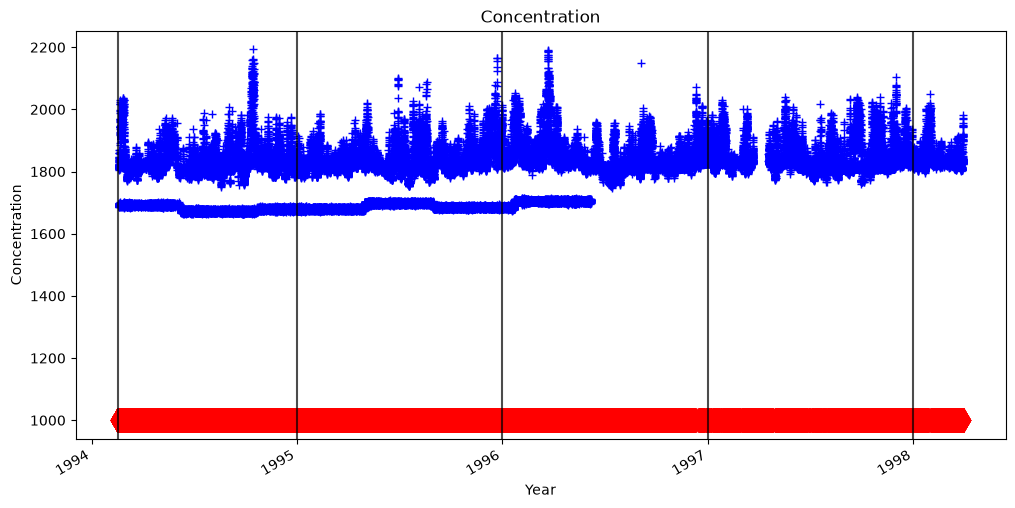

In [49]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates 

c = df['CH4_C'].iloc[:100000]
c.index = pd.to_datetime(c.index.astype(str).str.replace('datetime', '').str.strip())


# obtain NAN values
is_nan = c.isna()
c_filled = c.fillna(1000) #linear interpolation
print(c_filled)
plt.figure(figsize=(10, 5))

fig, ax = plt.subplots(figsize=(12,6))


valid_c = c.dropna()
print(valid_c)
ax.plot(
    valid_c.index,
    valid_c.values,
    marker='+',
    markersize=6,
    color='blue',
    linestyle='None',
    label='Normal'
)

ax.plot(
    c_filled[is_nan].index,
    c_filled[is_nan].values,
    marker='d',
    markersize=12,
    color='red',
    linestyle='None',
    label='Nan (missing)',
)

years = c.index.year.unique()

for i, year in enumerate(years[0:]):
    start_year = c[c.index.year == year] .index[0]

    ax.axvline(
        x=start_year,
        color='black',
        linestyle='-',
        alpha=0.7,
        label='Year Divider' if i ==0 else ""
    )
    print(start_year)


ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

plt.xlabel('Year')
plt.ylabel('Concentration')
plt.title('Concentration')
plt.show()
